# Heart Disease Prediction

**Author**: Siva

This notebook builds a machine learning model to predict whether a patient has heart disease based on clinical parameters.

**Dataset**: [Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset) — a cleaned version of the Cleveland Heart Disease dataset from the UCI Machine Learning Repository.

**Objective**: Predict the `target` column (1 = heart disease, 0 = no heart disease) using patient features such as age, cholesterol, blood pressure, and more.

**Libraries used**: pandas, numpy, matplotlib, seaborn, scikit-learn, kagglehub

## 1. Import Libraries

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

import kagglehub
import shap
import joblib
import os

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Download and Load the Dataset

In [51]:
# Download latest version from Kaggle
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")
print("Path to dataset files:", path)

# Load the CSV
csv_file = os.path.join(path, "heart.csv")
df = pd.read_csv(csv_file)
print(f"\nDataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Path to dataset files: /Users/sivaprasad/.cache/kagglehub/datasets/johnsmith88/heart-disease-dataset/versions/2

Dataset loaded successfully with 1025 rows and 14 columns.


## 3. Data Overview

Let's understand the structure, data types, and basic statistics of the dataset.

In [52]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [53]:
df.shape

(1025, 14)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [55]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Observations - Statistical Summary (`df.describe()`)

**Dataset Size:**
- The dataset has **1025 records** across all 14 columns with no missing values (count = 1025 for every column).

**Age:**
- Patients range from **29 to 77 years** old, with a mean age of ~54 years.
- 50% of patients are between 48 and 61 years (IQR), indicating the dataset mostly represents middle-aged to older adults.

**Sex:**
- Mean of 0.70 indicates **~70% of patients are male** (sex=1), so the dataset is male-dominated.

**Chest Pain Type (cp):**
- Values range from 0 to 3, with a mean of ~0.94, suggesting most patients have lower chest pain types (0 or 1).

**Resting Blood Pressure (trestbps):**
- Ranges from **94 to 200 mm Hg**, mean ~132 mm Hg.
- Normal resting BP is around 120 mm Hg — the mean being slightly above suggests some patients have mild hypertension.
- The 75th percentile is 140 mm Hg, which is the threshold for Stage 1 hypertension.

**Cholesterol (chol):**
- Ranges from **126 to 564 mg/dl**, mean ~246 mg/dl.
- Desirable cholesterol is below 200 mg/dl — the mean of 246 indicates many patients have **borderline high to high cholesterol**.
- Max of 564 is an extreme outlier worth noting.

**Fasting Blood Sugar (fbs):**
- Mean of 0.15 means only **~15% of patients** have fasting blood sugar > 120 mg/dl.
- This is a highly imbalanced binary feature.

**Resting ECG (restecg):**
- Values 0, 1, 2 with mean ~0.53, indicating roughly equal distribution between normal (0) and abnormal (1) results.

**Max Heart Rate (thalach):**
- Ranges from **71 to 202 bpm**, mean ~149 bpm.
- A wide range (std ~23) suggests significant variation in cardiac fitness across patients.
- The max of 202 is near the theoretical maximum heart rate for younger patients (220 - age).

**Exercise Induced Angina (exang):**
- Mean of 0.34 means **~34% of patients** experience exercise-induced angina.

**ST Depression - Oldpeak:**
- Ranges from **0 to 6.2**, mean ~1.07.
- 50th percentile (median) is 0.8 and 75th percentile is 1.8, indicating the distribution is **right-skewed** — most patients have low ST depression.
- Higher values indicate more severe exercise-induced cardiac stress.

**Slope:**
- Values 0, 1, 2 with mean ~1.39, suggesting most patients fall in slope categories 1 and 2.

**Major Vessels (ca):**
- Ranges from 0 to 4, with mean ~0.75.
- 75th percentile is 1.0, meaning **75% of patients have 0 or 1 major vessels** colored by fluoroscopy.

**Thalassemia (thal):**
- Mean of ~2.32 indicates most patients have value 2 (reversible defect) or 3.

**Target:**
- Mean of **0.51** indicates a nearly balanced dataset — ~51% have heart disease and ~49% don't. This is ideal for classification without needing resampling techniques.

In [56]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


In [57]:
# Check for duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")
print(f"Dataset size before removing duplicates: {df.shape[0]}")

df = df.drop_duplicates()
print(f"Dataset size after removing duplicates: {df.shape[0]}")

Number of duplicate rows: 723
Dataset size before removing duplicates: 1025
Dataset size after removing duplicates: 302


### Observations - Data Overview

- The dataset contains **14 columns**: 13 features and 1 target variable.
- All columns are numeric (int64 or float64) — no text/categorical encoding needed.
- **No missing values** are present, which means we can skip imputation.
- **723 duplicate rows** found out of 1025 (**70.5% duplicates!**). After removal, only **302 unique rows** remain.
  - Removing duplicates is critical here. If kept, the model would memorize repeated rows rather than learning patterns, leading to **inflated accuracy** and **data leakage** (same rows appearing in both train and test sets).

**Column descriptions:**

| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age of the patient in years | Continuous |
| `sex` | Sex (1 = male, 0 = female) | Binary |
| `cp` | Chest pain type (4 values: 0, 1, 2, 3) | Categorical |
| `trestbps` | Resting blood pressure (in mm Hg on admission to the hospital) | Continuous |
| `chol` | Serum cholesterol in mg/dl | Continuous |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Binary |
| `restecg` | Resting electrocardiographic results (values 0, 1, 2) | Categorical |
| `thalach` | Maximum heart rate achieved | Continuous |
| `exang` | Exercise induced angina (1 = yes, 0 = no) | Binary |
| `oldpeak` | ST depression induced by exercise relative to rest | Continuous |
| `slope` | The slope of the peak exercise ST segment (0, 1, 2) | Categorical |
| `ca` | Number of major vessels (0-3) colored by fluoroscopy | Categorical |
| `thal` | Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect) | Categorical |
| `target` | Heart disease diagnosis (1 = disease, 0 = no disease) | Binary (Target) |

## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution

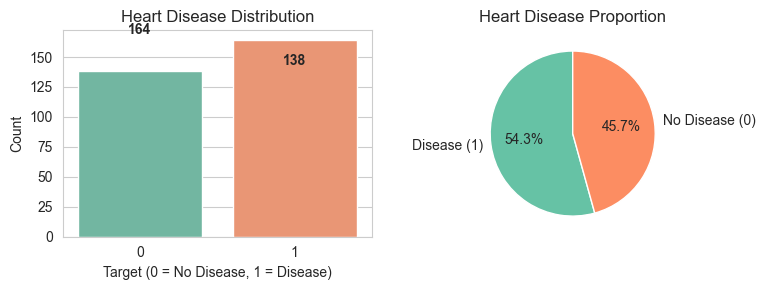

Class distribution:
target
1    164
0    138
Name: count, dtype: int64

Class balance ratio: 0.84


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Count plot
target_counts = df['target'].value_counts()
sns.countplot(x='target', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Heart Disease Distribution')
axes[0].set_xlabel('Target (0 = No Disease, 1 = Disease)')
axes[0].set_ylabel('Count')
for i, count in enumerate(target_counts):
    axes[0].text(i, count + 5, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts, labels=['Disease (1)', 'No Disease (0)'],
            autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Heart Disease Proportion')

plt.tight_layout()
plt.show()

print(f"Class distribution:\n{df['target'].value_counts()}")
print(f"\nClass balance ratio: {target_counts.min() / target_counts.max():.2f}")

### Observation - Target Distribution

- **164 patients** have heart disease (target=1) and **138 patients** don't (target=0).
- The class balance ratio is **0.84**, which is reasonably balanced.
- This means we don't need to apply oversampling/undersampling techniques like SMOTE.
- A balanced dataset ensures our model won't be biased toward predicting one class over the other.

### 4.2 Distribution of Continuous Features

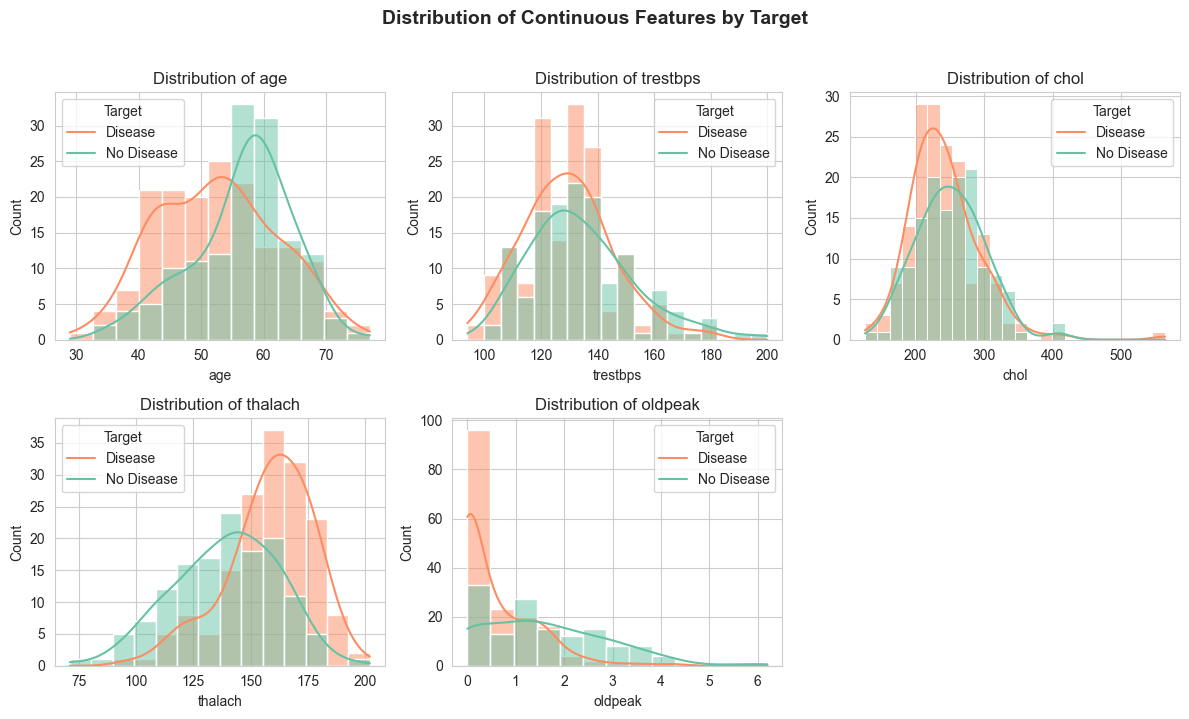

In [59]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend(title='Target', labels=['Disease', 'No Disease'])

axes[-1].set_visible(False)
plt.suptitle('Distribution of Continuous Features by Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Observation - Continuous Features

- **age**: Both classes have a similar spread (30-70 years). The Disease group (orange) peaks around age 50-55, while the No Disease group (green) peaks slightly later around 55-60. Age alone is not a strong separator but older patients show a slight lean toward no disease.

- **trestbps** (resting blood pressure): Both distributions are nearly overlapping with peaks around 120-130 mm Hg. This suggests resting blood pressure has **weak discriminating power** between the two classes.

- **chol** (cholesterol): Both classes show similar right-skewed distributions centered around 200-275 mg/dl. There is significant overlap, making cholesterol a **poor standalone predictor**. A few extreme outliers exist (>400 mg/dl).

- **thalach** (max heart rate): This is the **most visually separable** feature. Disease patients (orange) tend to achieve **higher max heart rates** (peak ~150-170 bpm), while no-disease patients (green) have a lower, wider distribution (peak ~130-150 bpm). This is likely a **strong predictor**.

- **oldpeak** (ST depression): Both distributions are **heavily right-skewed** with most values near 0. However, no-disease patients (green) tend to have **higher oldpeak values** (longer tail extending to 4-6), while disease patients cluster more tightly near 0. This makes oldpeak a useful discriminating feature.

### 4.3 Distribution of Categorical Features

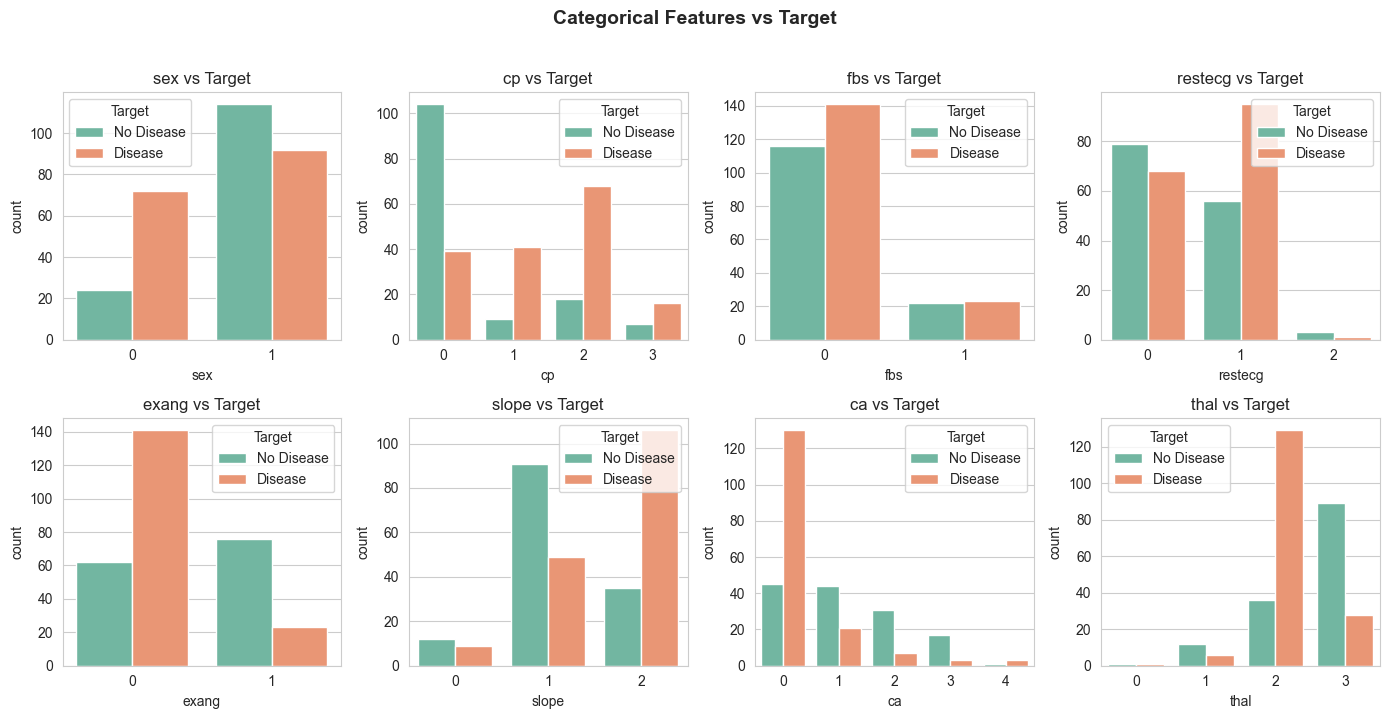

In [60]:
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(x=col, hue='target', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Target')
    axes[i].legend(title='Target', labels=['No Disease', 'Disease'])

plt.suptitle('Categorical Features vs Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Observation - Categorical Features

- **sex**: The dataset is male-dominated (sex=1). Among females (sex=0), ~75% have heart disease vs ~45% of males — **females in this dataset are at higher risk**. However, the small female sample size means this should be interpreted cautiously.

- **cp** (chest pain type): Type 0 (typical angina) is the most common and is dominated by **no-disease** patients (~100 vs ~40). Types 1, 2, and 3 show a **higher proportion of disease** cases, especially type 2 where disease patients significantly outnumber no-disease. Chest pain type is a **strong predictor**.

- **fbs** (fasting blood sugar): Overwhelmingly most patients have fbs=0 (~120 no-disease, ~140 disease). The fbs=1 group is small (~20 each) with nearly equal split. **Very weak discriminating power** — not useful on its own.

- **restecg**: Values 0 and 1 are common. Both show a slight lean toward disease cases but the distributions are similar. **Limited predictive value**.

- **exang** (exercise-induced angina): Clear separation here. Among exang=0 (no angina), disease patients dominate (~140 vs ~60). Among exang=1, no-disease patients dominate (~75 vs ~20). **Strong predictor** — absence of exercise angina is associated with disease.

- **slope**: Slope=1 is most common with no-disease patients leading (~115 vs ~65). Slope=2 shows the **reverse pattern** — disease patients outnumber no-disease. Slope=0 has very few cases. **Good discriminating feature**.

- **ca** (major vessels): ca=0 has the highest count with disease patients clearly dominating (~120 vs ~50). As ca increases (1, 2, 3, 4), no-disease patients tend to dominate. **Strong predictor** — fewer visible vessels correlates with disease.

- **thal**: Value 2 (reversible defect) is the most common and shows a strong lean toward **disease** (~95 vs ~40). Value 3 shows the opposite with no-disease dominating. Values 0 and 1 have very few cases. **Strong predictor**.

### 4.4 Correlation Heatmap

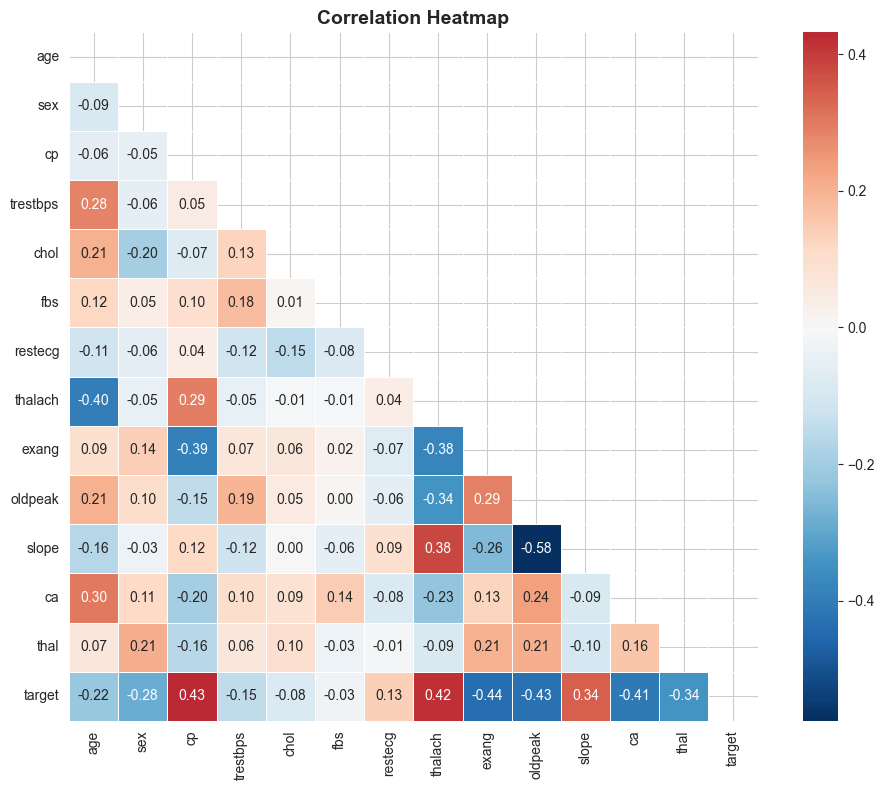

In [61]:
plt.figure(figsize=(10, 8))
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [62]:
# Top features correlated with target
target_corr = df.corr()['target'].drop('target').sort_values(ascending=False)
print("Feature correlations with target (sorted):\n")
print(target_corr.to_string())

Feature correlations with target (sorted):

cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601


### Observation - Correlation Analysis

**Correlations with Target (last row):**
- **Strongly positively correlated**: `cp` (0.43), `thalach` (0.42), `slope` (0.34) — higher values of these features are associated with heart disease.
- **Strongly negatively correlated**: `exang` (-0.44), `oldpeak` (-0.43), `ca` (-0.41), `thal` (-0.34), `sex` (-0.28) — higher values reduce the likelihood of disease.
- **Weakly correlated**: `fbs` (-0.03), `chol` (-0.08), `restecg` (0.13), `trestbps` (-0.15) — these features have minimal linear relationship with the target and may contribute little to prediction.

**Notable inter-feature correlations:**
- `slope` & `oldpeak` have the strongest inter-feature correlation at **-0.58** — as oldpeak increases, slope tends to decrease. This makes clinical sense as both relate to ST segment behavior during exercise.
- `thalach` & `age` show a correlation of **-0.40** — older patients tend to have lower max heart rates, which is physiologically expected.
- `cp` & `exang` are correlated at **-0.39** — patients with certain chest pain types are less likely to have exercise-induced angina.
- `thalach` & `exang` show **-0.38** — patients with exercise-induced angina tend to achieve lower max heart rates.
- `ca` & `age` have a correlation of **0.30** — older patients tend to have more major vessels visible.

**Multicollinearity check:**
- No pair of features exceeds |0.60| correlation, so **multicollinearity is not a concern**. All features can be safely included in the model without redundancy issues.